Enter 5 delivery coordinates (x y) within grid 0-9


Delivery 1:  1 2
Delivery 2:  3 4
Delivery 3:  5 4
Delivery 4:  6 3
Delivery 5:  7 1



Weather Severity: 0.0
Deliveries: [(1, 2), (3, 4), (5, 4), (6, 3), (7, 1)]

Drone 0 delivering to (1, 2)
Drone 0 -> (0, 1)
Drone 0 -> (0, 2)
Drone 0 -> (1, 2)
Drone 0 DELIVERED at (1, 2)
Drone 0 returning to base
Drone 0 -> (0, 2)
Drone 0 -> (0, 1)
Drone 0 -> (0, 0)
Drone 0 reached base


Drone 1 delivering to (3, 4)
Drone 1 -> (0, 1)
Drone 1 -> (0, 2)
Drone 1 -> (0, 3)
Drone 1 -> (0, 4)
Drone 1 -> (1, 4)
Drone 1 -> (2, 4)
Drone 1 -> (3, 4)
Drone 1 DELIVERED at (3, 4)
Drone 1 returning to base
Drone 1 -> (2, 4)
Drone 1 -> (1, 4)
Drone 1 -> (0, 4)
Drone 1 -> (0, 3)
Drone 1 -> (0, 2)
Drone 1 -> (0, 1)
Drone 1 -> (0, 0)
Drone 1 reached base


Drone 2 delivering to (5, 4)
Drone 2 -> (0, 1)
Drone 2 -> (0, 2)
Drone 2 -> (0, 3)
Drone 2 -> (0, 4)
Drone 2 -> (1, 4)
Drone 2 -> (2, 4)
Drone 2 -> (3, 4)
Drone 2 -> (4, 4)
Drone 2 -> (5, 4)
Drone 2 DELIVERED at (5, 4)
Drone 2 returning to base
Drone 2 -> (4, 4)
Drone 2 -> (3, 4)
Drone 2 -> (2, 4)
Drone 2 -> (1, 4)
Drone 2 -> (0, 4)
Drone 2 -> (0, 3

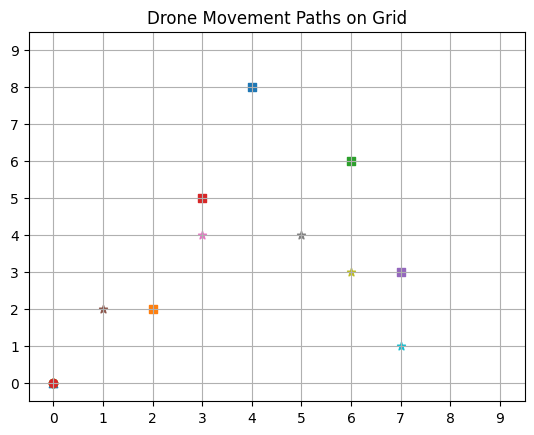

In [2]:
# ==========================================================
# BALANCED MULTI-DRONE DELIVERY SYSTEM
# Utility Optimization + Load Balancing + Coordination
# ==========================================================

import numpy as np
import heapq

# ---------------- PARAMETERS ----------------
GRID_SIZE = 10
NUM_DRONES = 3
BASE_MOVE_COST = 1
WEATHER_COEFF = 0.4
CRITICAL_BATTERY = 15

alpha = 1.0   # time weight
beta = 1.2    # energy weight
gamma = 1.5   # risk weight
delta = 5.0   # workload balancing weight

weather = np.random.uniform(0, 0.5)

# ---------------- OBSTACLES ----------------
obstacles = {(2,2),(3,5),(6,6),(7,3),(4,8)}

# ---------------- A* SEARCH ----------------
def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def neighbors(node):
    x,y = node
    moves = [(x+1,y),(x-1,y),(x,y+1),(x,y-1)]
    return [(i,j) for i,j in moves
            if 0<=i<GRID_SIZE and 0<=j<GRID_SIZE
            and (i,j) not in obstacles]

def astar(start, goal):
    pq = []
    heapq.heappush(pq,(0,start))
    came = {}
    cost = {start:0}

    while pq:
        _, curr = heapq.heappop(pq)
        if curr == goal:
            path=[]
            while curr in came:
                path.append(curr)
                curr = came[curr]
            return path[::-1]

        for n in neighbors(curr):
            new_cost = cost[curr] + 1
            if n not in cost or new_cost < cost[n]:
                cost[n] = new_cost
                priority = new_cost + heuristic(n,goal)
                heapq.heappush(pq,(priority,n))
                came[n] = curr
    return []

# ---------------- DRONE AGENT ----------------
class Drone:
    def __init__(self, idx):
        self.idx = idx
        self.base = (0,0)
        self.pos = (0,0)
        self.battery = 100
        self.energy_used = 0
        self.completed = []
        self.full_path = [(0,0)]

    def energy_cost(self):
        return BASE_MOVE_COST + WEATHER_COEFF*weather

    def estimate_cost(self, target):
        dist = heuristic(self.pos,target)
        energy = dist*self.energy_cost()
        risk = weather
        workload_penalty = delta * len(self.completed)
        return alpha*dist + beta*energy + gamma*risk + workload_penalty

    def move_path(self, path):
        for step in path:
            if self.battery < CRITICAL_BATTERY:
                print(f"Drone {self.idx} LOW BATTERY!")
                return False
            print(f"Drone {self.idx} -> {step}")
            self.pos = step
            cost = self.energy_cost()
            self.battery -= cost
            self.energy_used += cost
        return True

    def deliver(self, target):
        print(f"\nDrone {self.idx} delivering to {target}")
        path_to = astar(self.pos,target)
        if not path_to:
            print("No path found!")
            return False
        
        if not self.move_path(path_to):
            return False

        print(f"Drone {self.idx} DELIVERED at {target}")
        self.completed.append(target)

        print(f"Drone {self.idx} returning to base")
        return_path = astar(self.pos,self.base)
        self.move_path(return_path)
        self.pos = self.base
        print(f"Drone {self.idx} reached base\n")
        return True

# ---------------- UTILITY COORDINATOR ----------------
class UtilityCoordinator:
    def __init__(self,drones):
        self.drones = drones

    def assign(self,target):
        costs = [(d,d.estimate_cost(target)) for d in self.drones]
        chosen = min(costs,key=lambda x:x[1])[0]
        return chosen

# ---------------- USER INPUT ----------------
print("Enter 5 delivery coordinates (x y) within grid 0-9")
deliveries=[]
for i in range(5):
    x,y = map(int,input(f"Delivery {i+1}: ").split())
    deliveries.append((x,y))

# ---------------- SYSTEM EXECUTION ----------------
drones=[Drone(i) for i in range(NUM_DRONES)]
coordinator=UtilityCoordinator(drones)

print("\nWeather Severity:",round(weather,2))
print("Deliveries:",deliveries)

for target in deliveries:
    drone=coordinator.assign(target)
    drone.deliver(target)

# ---------------- FINAL REPORT ----------------
print("\n========= FINAL REPORT =========")
for d in drones:
    print(f"Drone {d.idx}")
    print(" Completed Deliveries:",d.completed)
    print(" Energy Used:",round(d.energy_used,2))
    print(" Battery Left:",round(d.battery,2))
    print("--------------------------------")
    # ---------------- FINAL GRID MOVEMENT GRAPH ----------------
import matplotlib.pyplot as plt

plt.figure()
plt.xlim(-0.5, GRID_SIZE-0.5)
plt.ylim(-0.5, GRID_SIZE-0.5)
plt.xticks(range(GRID_SIZE))
plt.yticks(range(GRID_SIZE))
plt.grid(True)

# Plot Obstacles
for o in obstacles:
    plt.scatter(o[0], o[1], marker='s')

# Plot Deliveries
for d in deliveries:
    plt.scatter(d[0], d[1], marker='*')

# Plot Base
plt.scatter(0, 0, marker='^')

# Plot Drone Paths
for drone in drones:
    x_coords = [p[0] for p in drone.full_path]
    y_coords = [p[1] for p in drone.full_path]

    if drone.idx == 0:
        plt.plot(x_coords, y_coords)
    elif drone.idx == 1:
        plt.plot(x_coords, y_coords)
    else:
        plt.plot(x_coords, y_coords)

    plt.scatter(x_coords, y_coords)

plt.title("Drone Movement Paths on Grid")
plt.show()